## **Classwork: "What Did the Network See?" — Inside CNN Feature Maps**

**The Scenario**

Your CNN is training — but is it *actually* learning anything useful? This is the question every practitioner must answer before trusting a model. Today you will go inside the network: visualise what individual filters detect, understand how the *receptive field* grows layer by layer, and inspect how a bank of filters collectively describes an image. By the end, you will have the tools to diagnose a CNN the same way an engineer reads an X-ray.

## **Part 1: Conceptual Questions**

### **Question 1: What is a Feature Map?**

After a single convolutional layer with one 3×3 filter processes a grayscale image, you get a 2D output grid. What does each value in this output grid represent?

A) The original pixel brightness at that location, averaged over a 3×3 neighbourhood.

B) The degree to which the filter's pattern (e.g. a vertical edge, a diagonal) was present at that spatial location in the input.

C) The probability that a specific class (cat, dog, etc.) is present at that location.

D) The gradient of the loss with respect to the pixel at that location.

Answer: (B) The degree to which the filter's pattern (e.g. a vertical edge, a diagonal) was present at that spatial location in the input.

It uses convolution to figure out the similarity between the obseved grid and the filter.

### **Question 2: The Receptive Field**

Consider a CNN with **two successive** convolutional layers, each using a 3×3 kernel with stride 1 and no padding.

A single neuron in the *second* feature map (after the second convolution) corresponds to what region of the original input image?

A) A 3×3 region — the kernel is 3×3, so it always sees the same area.

B) A 5×5 region — stacking two 3×3 convolutions means each output neuron aggregates information from a 5×5 patch of the input.

C) A 9×9 region — the two kernels multiply (3×3 = 9).

D) The entire image — every convolution has a global receptive field.

Answer: (B) A 5×5 region.

A neuron in the second convolution layer combines a 3×3 neighborhood from Layer 1, and each Layer 1 value already comes from a 3×3 patch of the input. With stride 1 and no padding, stacking two 3×3 convolutions expands the receptive field to:

\[
3 + (3 - 1) = 5
\]

So each Layer 2 neuron corresponds to a 5x5 area in the original image.


### **Question 3: Many Filters, Many Feature Maps**

A convolutional layer has **32 filters**, each of size 3×3. It processes a **64×64 RGB image** (3 channels). What is the shape of the output volume (feature map stack), assuming stride 1 and no padding?

A) (64, 64, 3) — the input shape is preserved and the filters are not stacked.

B) (62, 62, 32) — each filter produces one 62×62 feature map, and 32 filters produce 32 feature maps.

C) (62, 62, 3) — the number of output channels equals the number of input channels.

D) (64, 64, 32) — convolution never changes spatial size.

Answer: (B) (62, 62, 32)

For a convolution with kernel \(3\times3\), stride \(1\), and no padding:
- Output height \(= 64 - 3 + 1 = 62\)
- Output width \(= 64 - 3 + 1 = 62\)

Each of the 32 filters produces one feature map, so depth \(= 32\).

So the output volume is \((62, 62, 32)\).


## **Part 2: Numerical Reasoning**

### **Question 4: Receptive Field Calculation**

You are designing a CNN with the following architecture:

| Layer | Type | Kernel | Stride |
|---|---|---|---|
| 1 | Conv | 3×3 | 1 |
| 2 | MaxPool | 2×2 | 2 |
| 3 | Conv | 3×3 | 1 |

The receptive field of a neuron after layer $l$ can be computed iteratively:
$$RF_l = RF_{l-1} + (k_l - 1) \times \prod_{i=1}^{l-1} s_i$$
where $k_l$ is the kernel size and $s_i$ is the stride at layer $i$. Start with $RF_0 = 1$.

Calculate the receptive field of a neuron in the **output of Layer 3** with respect to the original input image. Show your working step by step.

Using  
\[
RF_l = RF_{l-1} + (k_l - 1)\times \prod_{i=1}^{l-1} s_i,\quad RF_0=1
\]

- **After Layer 1 (Conv 3×3, stride 1):**  
    \[
    RF_1 = 1 + (3-1)\times 1 = 3
    \]
    So each neuron sees a **3×3** region of the input.

- **After Layer 2 (MaxPool 2×2, stride 2):**  
    Previous stride product \(= s_1 = 1\)  
    \[
    RF_2 = 3 + (2-1)\times 1 = 4
    \]
    So each pooled neuron corresponds to a **4×4** region of the original input.

- **After Layer 3 (Conv 3×3, stride 1):**  
    Previous stride product \(= s_1 s_2 = 1\times 2 = 2\)  
    \[
    RF_3 = 4 + (3-1)\times 2 = 8
    \]
    So each neuron in Layer 3 output has receptive field **8×8** on the original input.


## **Part 3: Coding Challenge — Visualising What Filters Learn**

You will now build a multi-filter CNN layer from scratch and visualise *all* of its feature maps at once. This is exactly what researchers do to verify that a trained network is picking up meaningful patterns.

**Fill in the lines marked `## FILL IN`.**

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# --- Synthetic test image: a cross on a noisy background ---
np.random.seed(0)
image = np.random.rand(32, 32) * 0.15  # low-level noise
image[14:18, 4:28] = 1.0   # horizontal bar
image[4:28, 14:18] = 1.0   # vertical bar

# --- A bank of 6 hand-crafted filters ---
filters = {
    "Vertical edge":    np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=float),
    "Horizontal edge":  np.array([[-1,-2,-1], [ 0, 0, 0], [ 1, 2, 1]], dtype=float),
    "Diagonal (\\)": np.array([[ 2, 1,-1], [ 1, 0,-1], [-1,-1,-2]], dtype=float),
    "Laplacian":        np.array([[ 0,-1, 0], [-1, 4,-1], [ 0,-1, 0]], dtype=float),
    "Blur":             np.ones((3, 3), dtype=float) / 9,
    "Emboss":           np.array([[-2,-1, 0], [-1, 1, 1], [ 0, 1, 2]], dtype=float),
}

print(f"Image shape: {image.shape}")
print(f"Number of filters: {len(filters)}")

Image shape: (32, 32)
Number of filters: 6


In [3]:
# --- Reuse your implementations from the previous notebook ---

def conv2d(image, kernel, stride=1, padding=0):
    H, W = image.shape
    K = kernel.shape[0]
    if padding > 0:
        image = np.pad(image, padding, mode='constant')
    out_H = (H - K + 2 * padding) // stride + 1
    out_W = (W - K + 2 * padding) // stride + 1
    feature_map = np.zeros((out_H, out_W))
    for i in range(out_H):
        for j in range(out_W):
            patch = image[i*stride : i*stride+K, j*stride : j*stride+K]
            feature_map[i, j] = np.sum(patch * kernel)
    return feature_map

def relu(x):
    return np.maximum(0, x)

def max_pool2d(feature_map, pool_size=2, stride=2):
    H, W = feature_map.shape
    out_H = (H - pool_size) // stride + 1
    out_W = (W - pool_size) // stride + 1
    pooled = np.zeros((out_H, out_W))
    for i in range(out_H):
        for j in range(out_W):
            patch = feature_map[i*stride : i*stride+pool_size, j*stride : j*stride+pool_size]
            pooled[i, j] = np.max(patch)
    return pooled

print("Helper functions loaded.")

Helper functions loaded.


In [5]:
# ---------------------------------------------------------------
# Task A: Apply every filter in the bank to the image
# and store the result (after ReLU) in a dictionary.
# ---------------------------------------------------------------

feature_maps = {}  # will store {filter_name: feature_map_after_relu}

for name, kernel in filters.items():
    ## FILL IN:
    ## 1. Apply conv2d to `image` with the current `kernel` (stride=1, padding=0)
    ## 2. Apply relu to the result
    ## 3. Store in feature_maps[name]
    fmap = conv2d(image, kernel, stride=1, padding=0)
    fmap_relu = relu(fmap)
    feature_maps[name] = fmap_relu

print("Feature map shapes:")
for name, fm in feature_maps.items():
    print(f"  {name}: {fm.shape}")

Feature map shapes:
  Vertical edge: (30, 30)
  Horizontal edge: (30, 30)
  Diagonal (\): (30, 30)
  Laplacian: (30, 30)
  Blur: (30, 30)
  Emboss: (30, 30)


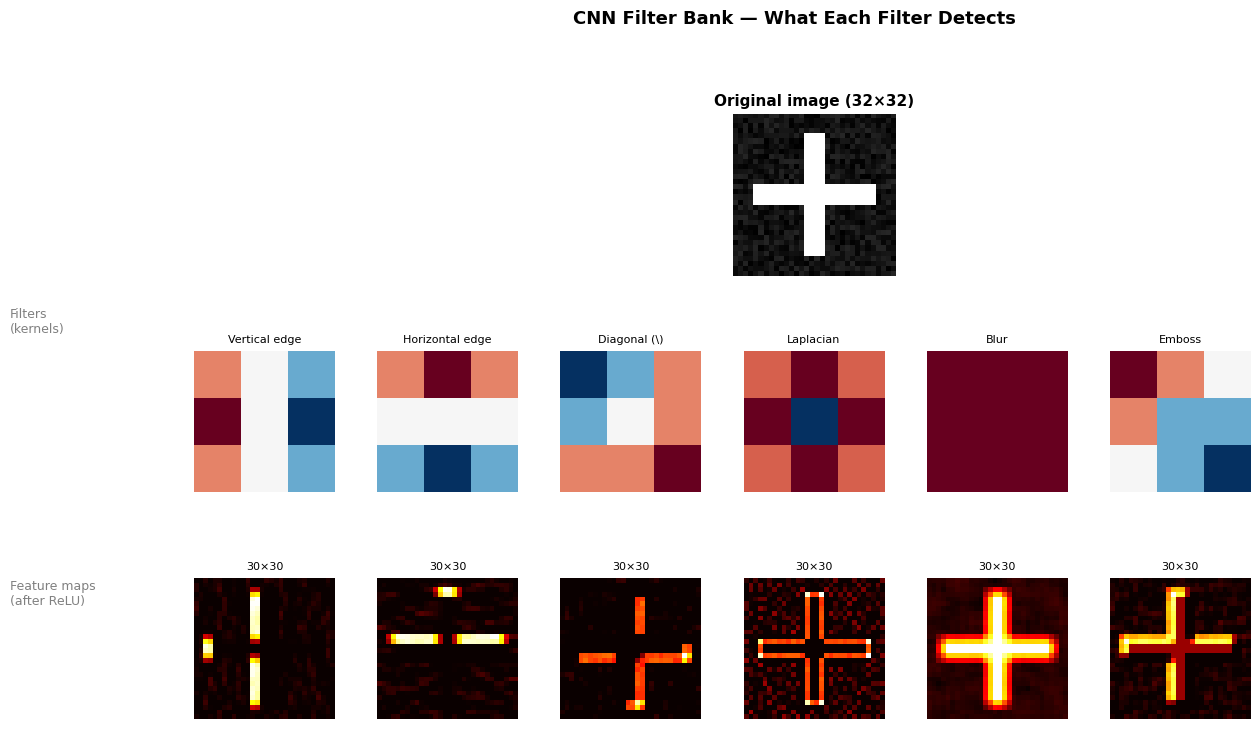

In [7]:
# ---------------------------------------------------------------
# Task B: Visualise the filter bank and all feature maps
# in a single organised grid.
# ---------------------------------------------------------------

n = len(filters)
fig = plt.figure(figsize=(16, 8))
gs = gridspec.GridSpec(3, n + 1, figure=fig,
                        hspace=0.4, wspace=0.3)

# Row 0: original image (spanning full width)
ax_orig = fig.add_subplot(gs[0, :])
ax_orig.imshow(image, cmap='gray')
ax_orig.set_title('Original image (32×32)', fontsize=11, fontweight='bold')
ax_orig.axis('off')

# Row 1: filter kernels
for col, (name, kernel) in enumerate(filters.items()):
    ax = fig.add_subplot(gs[1, col])
    ax.imshow(kernel, cmap='RdBu')
    ax.set_title(name, fontsize=8)
    ax.axis('off')
    ## Add ax.set_title(name, fontsize=8) and ax.axis('off')
    

# Row 2: feature maps after ReLU
for col, (name, fm) in enumerate(feature_maps.items()):
    ax = fig.add_subplot(gs[2, col])
    ax.imshow(fm, cmap='hot')
    ax.set_title(f'{fm.shape[0]}×{fm.shape[1]}', fontsize=8)
    ax.axis('off')
    ## FILL IN: display `fm` using imshow with cmap='hot'
    ## Add ax.set_title(f'{fm.shape[0]}×{fm.shape[1]}', fontsize=8)
    ## and ax.axis('off')
    

# Row labels
fig.text(0.01, 0.62, 'Filters\n(kernels)', va='center', ha='left',
         fontsize=9, color='gray', rotation=0)
fig.text(0.01, 0.28, 'Feature maps\n(after ReLU)', va='center', ha='left',
         fontsize=9, color='gray', rotation=0)

plt.suptitle('CNN Filter Bank — What Each Filter Detects', fontsize=13, fontweight='bold', y=1.01)
plt.show()

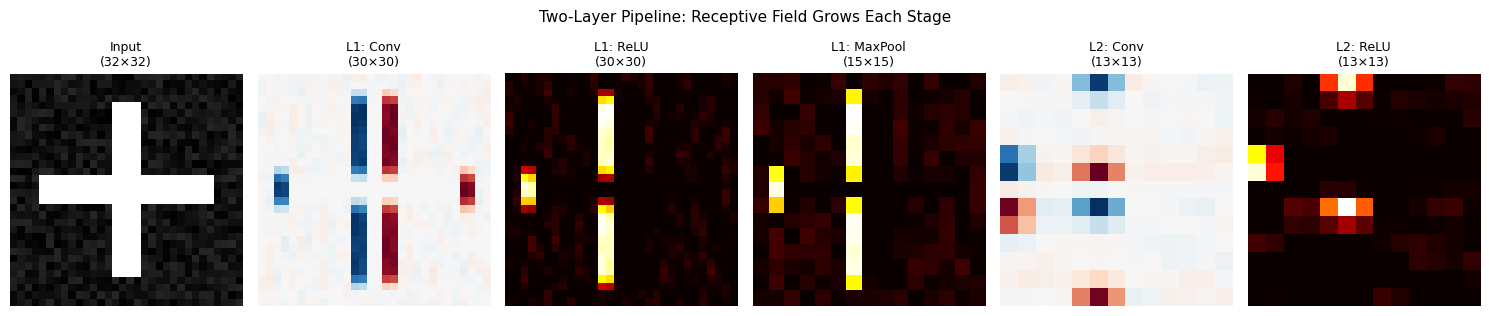


Spatial size at each stage:
  Input               : (32, 32)
  L1: Conv            : (30, 30)
  L1: ReLU            : (30, 30)
  L1: MaxPool         : (15, 15)
  L2: Conv            : (13, 13)
  L2: ReLU            : (13, 13)


In [8]:
# ---------------------------------------------------------------
# Task C: Two-layer pipeline — observe how the receptive field grows
# ---------------------------------------------------------------
# Layer 1: Conv (vertical edge) + ReLU + MaxPool
# Layer 2: Conv (horizontal edge) + ReLU
# Visualise the output at each stage.

kernel_v = filters["Vertical edge"]
kernel_h = filters["Horizontal edge"]

# --- Layer 1 ---
## FILL IN: conv2d → relu → max_pool2d (pool_size=2, stride=2)
l1_conv = conv2d(image, kernel_v, stride=1, padding=0)
l1_relu = relu(l1_conv)
l1_pool = max_pool2d(l1_relu, pool_size=2, stride=2)

# --- Layer 2 ---
## FILL IN: conv2d on l1_pool → relu
l2_conv = conv2d(l1_pool, kernel_h, stride=1, padding=0)
l2_relu = relu(l2_conv)

# --- Visualise ---
stages = [
    (image,   'Input\n(32×32)',          'gray'),
    (l1_conv, 'L1: Conv\n(30×30)',       'RdBu'),
    (l1_relu, 'L1: ReLU\n(30×30)',       'hot'),
    (l1_pool, 'L1: MaxPool\n(15×15)',    'hot'),
    (l2_conv, 'L2: Conv\n(13×13)',       'RdBu'),
    (l2_relu, 'L2: ReLU\n(13×13)',       'hot'),
]

fig, axes = plt.subplots(1, 6, figsize=(15, 3))
for ax, (data, title, cmap) in zip(axes, stages):
    ax.imshow(data, cmap=cmap)
    ax.set_title(title, fontsize=9)
    ax.axis('off')

plt.suptitle('Two-Layer Pipeline: Receptive Field Grows Each Stage', fontsize=11, y=1.05)
plt.tight_layout()
plt.show()

print(f"\nSpatial size at each stage:")
for (data, title, _) in stages:
    print(f"  {title.split(chr(10))[0]:20s}: {data.shape}")

## **Observations**

> Answer the following after running all three tasks:
>
> **Task A/B:**
> 1. Which filters produce a strong response on the horizontal bar of the cross? Which respond to the vertical bar? Does this match the structure of the kernels?
> 2. The Laplacian filter responds to *both* edges simultaneously. Looking at its kernel values, why would you expect this?
> 3. The Blur filter produces a very faint feature map after ReLU. Why does a blurring kernel produce weaker edge activations?
>
> **Task C:**
> 4. The output of Layer 2 is 13×13, starting from 32×32. Each neuron here has a receptive field you calculated in Q4. Can you see (roughly) in the Layer 2 output where the cross was, even though the spatial map is much smaller?
> 5. In general, why do we *want* the receptive field to grow as we go deeper in a CNN?


## **Answers**

1. **Strong responses by orientation:**  
    - **Horizontal bar:** strongest in the **Horizontal edge** filter (and also visible in Laplacian).  
    - **Vertical bar:** strongest in the **Vertical edge** filter (also visible in Laplacian).  
    Yes — this matches the kernels: Sobel-like orientation-specific weights fire when intensity changes align with their direction.

2. **Why Laplacian responds to both edges:**  
    The Laplacian kernel has a positive center and negative neighbors, so it detects **second-order intensity changes in all directions** (not orientation-specific). Hence both horizontal and vertical boundaries of the cross activate it.

3. **Why Blur is faint after ReLU:**  
    A blur kernel averages neighboring pixels, smoothing transitions and suppressing high-frequency edge contrast. Since edges produce weaker responses, ReLU leaves only small positive values, making the map faint.

4. **Cross localization in 13×13 map:**  
    Yes. Even after downsampling, high activations still cluster around the center region corresponding to where the cross exists in the input, so the structure is still roughly localized.

5. **Why growing receptive field is useful:**  
    Deeper layers need larger context to combine local edges into meaningful parts/shapes. A growing receptive field enables the network to move from **local patterns** (edges/textures) to **global structure** (object-level understanding).


## **(Bonus) Extension: What Maximally Activates a Filter?**

A powerful interpretability technique is to find the input patch that produces the **highest activation** in a given filter — this tells you exactly what pattern the filter is tuned to detect.

Complete the function below to scan the image and find the 3×3 patch that maximally activates the Vertical Edge filter.

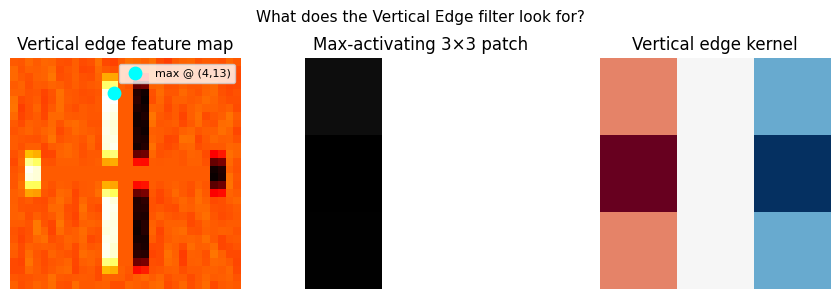

Max activation at row=4, col=13
Patch values:
[[0.06 1.   1.  ]
 [0.   1.   1.  ]
 [0.01 1.   1.  ]]


In [9]:
def find_max_activating_patch(image, kernel):
    """
    Returns the 3x3 patch from `image` that produces
    the highest response when convolved with `kernel`.
    """
    fmap = conv2d(image, kernel)  # full feature map
    K = kernel.shape[0]

    ## FILL IN:
    ## 1. Find the (row, col) of the maximum value in fmap
    ##    Hint: use np.unravel_index(np.argmax(fmap), fmap.shape)
    ## 2. Extract and return the K×K patch from image at that location
    max_loc = np.unravel_index(np.argmax(fmap), fmap.shape)
    row, col = max_loc
    best_patch = image[row:row + K, col:col + K]
    return best_patch, row, col, fmap


patch, r, c, fmap = find_max_activating_patch(image, filters["Vertical edge"])

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
axes[0].imshow(fmap, cmap='hot')
axes[0].set_title('Vertical edge feature map')
axes[0].scatter([c], [r], color='cyan', s=80, zorder=5, label=f'max @ ({r},{c})')
axes[0].legend(fontsize=8)
axes[0].axis('off')

axes[1].imshow(patch, cmap='gray')
axes[1].set_title(f'Max-activating 3×3 patch')
axes[1].axis('off')

axes[2].imshow(filters["Vertical edge"], cmap='RdBu')
axes[2].set_title('Vertical edge kernel')
axes[2].axis('off')

plt.suptitle('What does the Vertical Edge filter look for?', fontsize=11)
plt.tight_layout()
plt.show()

print(f"Max activation at row={r}, col={c}")
print(f"Patch values:\n{patch.round(2)}")

**Bonus Reflection:** Does the max-activating patch visually resemble the filter kernel? What does this tell you about what the filter has "learned" to detect?
Yes—roughly. The max-activating patch shows a strong **left-to-right intensity jump** (darker values next to bright \(1.0\) values), which matches what the Vertical Edge kernel is designed to respond to. This indicates the filter has effectively learned/tuned itself to detect **vertical boundaries (edge transitions)** rather than absolute brightness.
...
